# Humidifier Model — Dew Point Control

This notebook models the inlet gas humidification system for the PEMFC auxiliary circuit.
RH at the gas inlets is regulated through **dew point temperature** tracking.

The controller measures the inlet temperature $T_{in}$ and adjusts water injection
to maintain a prescribed dew point setpoint $T_{dp,des}$:

$$\Phi_{des}(t) = \frac{P_{sat}(T_{dp,des})}{P_{sat}(T_{in}(t))}$$

The actuator follows first-order lag dynamics:

$$\tau_{hum}\,\frac{d\dot{W}_{inj}}{dt} = \dot{W}_{inj,des}(t) - \dot{W}_{inj}(t)$$

| Signal | Symbol | Description |
|--------|--------|-------------|
| Measurement | $T_{in}$ | Inlet gas temperature (supply manifold) |
| Setpoint | $T_{dp,des}$ | Desired dew point temperature |
| Output | $\dot{W}_{inj}$ | Water injection mass flow (kg/s) |

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import solve_ivp

sys.path.append('../../')
from configuration.settings import R, M_H2O, M_H2, M_N2, M_O2
from configuration.settings import tau_hum, Pext, Text, Phi_ext, yO2_ext
from model.coefficients import Psat, C_v_sat

plt.rcParams.update({
    'font.size': 11,
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.35,
})

## 1   Saturation Pressure and Dew Point

The saturation vapour pressure $P_{sat}(T)$ is evaluated with the Antoine polynomial
already implemented in `model/coefficients.py`.

The **dew point temperature** $T_{dp}$ is the temperature at which a stream becomes
saturated with vapour:

$$P_{sat}(T_{dp}) = \Phi \cdot P_{sat}(T_{in})$$

It is obtained by numerically inverting $P_{sat}$ (root-finding on the Antoine curve).

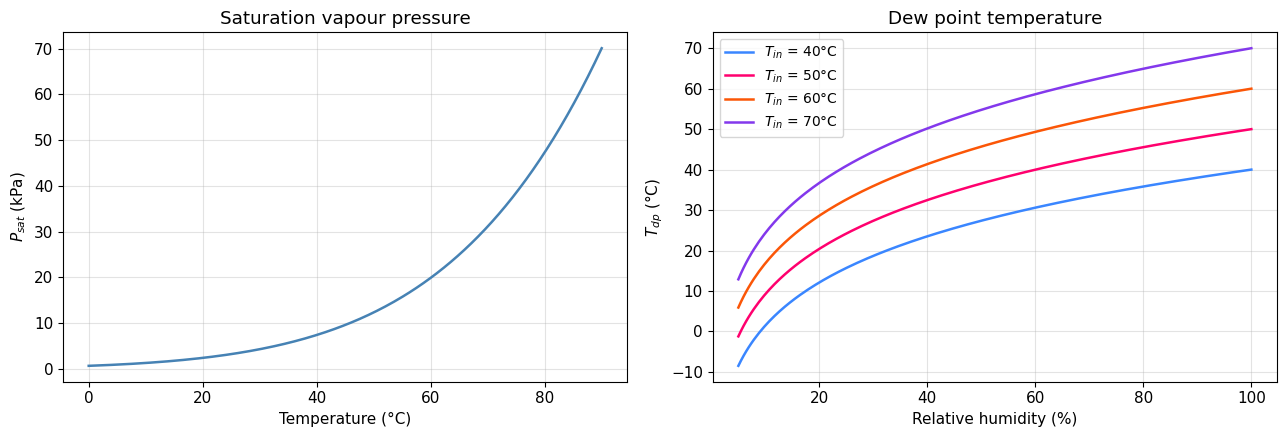

In [2]:
def Tdp(T_in, Phi):
    """Dew point temperature (K) from inlet temperature T_in (K) and RH Phi (-)."""
    Phi = float(np.clip(Phi, 1e-9, 1.0))
    Pv  = Phi * Psat(T_in)
    return brentq(lambda T: Psat(T) - Pv, 233.15, T_in + 0.01)


T_range   = np.linspace(273.15, 363.15, 300)
Phi_range = np.linspace(0.05, 1.0, 200)
colors_dp = ['#3a86ff', '#ff006e', '#fb5607', '#8338ec']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: saturation pressure vs temperature
axes[0].plot(T_range - 273.15, Psat(T_range) / 1e3, color='steelblue')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel(r'$P_{sat}$ (kPa)')
axes[0].set_title('Saturation vapour pressure')

# Right: dew point vs RH for several inlet temperatures
for T_in_val, col in zip([313.15, 323.15, 333.15, 343.15], colors_dp):
    Tdp_arr = np.array([Tdp(T_in_val, phi) - 273.15 for phi in Phi_range])
    axes[1].plot(
        Phi_range * 100, Tdp_arr,
        label=f'$T_{{in}}$ = {T_in_val - 273.15:.0f}°C', color=col)

axes[1].set_xlabel('Relative humidity (%)')
axes[1].set_ylabel('$T_{dp}$ (°C)')
axes[1].set_title('Dew point temperature')
axes[1].legend(fontsize=10)
fig.tight_layout()
plt.show()

## 2   Dew Point Control: Dynamic RH Setpoint

Fixing $T_{dp,des}$ while $T_{in}$ varies produces a **time-varying RH setpoint**:

$$\Phi_{des}(t) = \frac{P_{sat}(T_{dp,des})}{P_{sat}(T_{in}(t))}$$

| Disturbance | Effect on $\Phi_{des}$ | Physical meaning |
|-------------|----------------------|------------------|
| $T_{in}$ rises | $\Phi_{des}$ decreases | Less injection — avoids flooding |
| $T_{in}$ falls | $\Phi_{des}$ increases | More injection — avoids dry-out |

### Dew Point Depression

The **dew point depression** $\Delta T$ is the temperature gap between the inlet gas and its dew point:

$$\Delta T = T_{in} - T_{dp,des}$$

Inverting this, the desired dew point is $T_{dp,des} = T_{in} - \Delta T$, so the RH setpoint becomes:

$$\Phi_{des} = \frac{P_{sat}(T_{in} - \Delta T)}{P_{sat}(T_{in})}$$

Because $P_{sat}$ is **nonlinear**, the same depression $\Delta T$ gives a different $\Phi_{des}$ at different
inlet temperatures.
A fixed depression of 10 K gives roughly 65 % RH at 70 °C but only 55 % at 40 °C.
The depression $\Delta T$ is therefore a more stable design parameter than a fixed RH target.

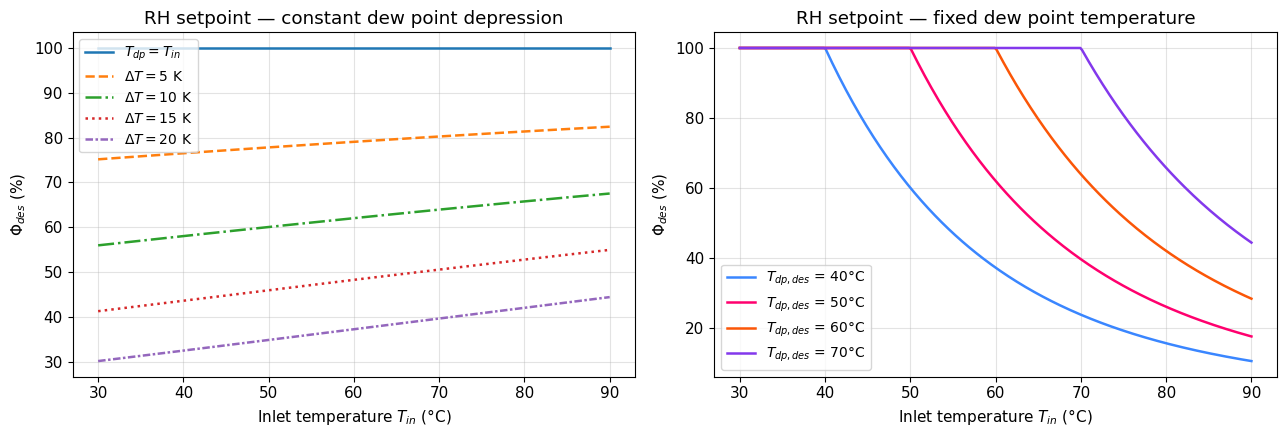

In [3]:
def Phi_des_from_dp(T_in, T_dp_des):
    """RH setpoint (-) from inlet temperature and dew point setpoint (K)."""
    return float(np.clip(Psat(T_dp_des) / Psat(T_in), 0.0, 1.0))


T_in_range = np.linspace(303.15, 363.15, 300)   # 30 – 90 °C

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: RH setpoint for constant dew point depression
for dT, ls in zip([0, 5, 10, 15, 20], ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]):
    Phi_arr = np.array([Phi_des_from_dp(T, T - dT) for T in T_in_range])
    lbl = r'$T_{dp} = T_{in}$' if dT == 0 else r'$\Delta T = $' + f'{dT} K'
    axes[0].plot(T_in_range - 273.15, Phi_arr * 100, linestyle=ls, label=lbl)

axes[0].set_xlabel('Inlet temperature $T_{in}$ (°C)')
axes[0].set_ylabel(r'$\Phi_{des}$ (%)')
axes[0].set_title('RH setpoint — constant dew point depression')
axes[0].legend(fontsize=10)

# Right: RH setpoint for a fixed absolute dew point temperature
for T_dp_val, col in zip([313.15, 323.15, 333.15, 343.15], colors_dp):
    Phi_arr = np.array([Phi_des_from_dp(T, T_dp_val) for T in T_in_range])
    axes[1].plot(
        T_in_range - 273.15, Phi_arr * 100,
        label=f'$T_{{dp,des}}$ = {T_dp_val - 273.15:.0f}°C', color=col)

axes[1].set_xlabel('Inlet temperature $T_{in}$ (°C)')
axes[1].set_ylabel(r'$\Phi_{des}$ (%)')
axes[1].set_title('RH setpoint — fixed dew point temperature')
axes[1].legend(fontsize=10)

fig.tight_layout()
plt.show()

## 3   Humidifier Model

### 3.1   Water injection setpoint

The desired vapour mass flow at supply manifold pressure $P_{sm}$ is:

$$\dot{W}_{v,des} = M_{H_2O}\,\frac{\Phi_{des}\cdot P_{sat}(T_{in})}{P_{sm}}\cdot\frac{\dot{W}_{gas}}{M_{gas,dry}}$$

Substituting $\Phi_{des} = P_{sat}(T_{dp,des})/P_{sat}(T_{in})$,
the $P_{sat}(T_{in})$ term **cancels**:

$$\boxed{\dot{W}_{v,des} = M_{H_2O}\,\frac{P_{sat}(T_{dp,des})}{P_{sm}}\cdot\frac{\dot{W}_{gas}}{M_{gas,dry}}}$$

> The required vapour flow depends only on $T_{dp,des}$, not on $T_{in}$.
> Thermal disturbances at the inlet **do not change the injection setpoint**
> (for constant gas flow and pressure).

Subtracting the vapour already carried by the incoming stream:

$$\dot{W}_{inj,des} = \max\bigl(0,\;\dot{W}_{v,des} - \dot{W}_{v,in}\bigr)$$

### 3.2   First-order actuator dynamics

$$\frac{d\dot{W}_{inj}}{dt} = \frac{\dot{W}_{inj,des} - \dot{W}_{inj}}{\tau_{hum}},
\qquad \tau_{hum} = 15\;\mathrm{s}$$

### 3.3   Integration with `model/states.py`

In `dif_eq_int_values()`, replace the static RH setpoints with dew point-based ones:

```python
# Before — constant RH setpoint
Phi_a_des = control_variables['Phi_a_des']

# After — dew point control
T_dp_a_des = control_variables['T_dp_a_des']   # new control variable
Phi_a_des  = Psat(T_dp_a_des) / Psat(Tfc)      # dynamic RH from measurement
```

The downstream `Wa_inj_des` and `Wc_inj_des` computations are unchanged.

In [4]:
class Humidifier:
    """
    Humidifier model with dew point-based RH control.

    The RH setpoint is computed dynamically from the measured inlet temperature
    and a fixed dew point temperature setpoint.

    Parameters
    ----------
    side : {'anode', 'cathode'}
    T_dp_des : float
        Dew point temperature setpoint (K).
    tau : float
        First-order actuator time constant (s).  Default: tau_hum from settings.
    """

    def __init__(self, side, T_dp_des, tau=tau_hum):
        if side not in ('anode', 'cathode'):
            raise ValueError("side must be 'anode' or 'cathode'")
        self.side     = side
        self.T_dp_des = T_dp_des
        self.tau      = tau

    # ------------------------------------------------------------------ #
    #  Setpoint computations                                               #
    # ------------------------------------------------------------------ #

    def Phi_setpoint(self, T_in):
        """
        RH setpoint from the inlet temperature measurement.

        Parameters
        ----------
        T_in : float  Measured inlet gas temperature (K).

        Returns
        -------
        float  Desired relative humidity clipped to [0, 1].
        """
        return float(np.clip(Psat(self.T_dp_des) / Psat(T_in), 0.0, 1.0))

    def Winj_setpoint(self, P_sm, W_gas, M_gas_dry, W_v_in=0.0):
        """
        Desired water injection mass flow (kg/s).

        Note: T_in is NOT a parameter here — P_sat(T_in) cancels in the formula.

        Parameters
        ----------
        P_sm      : supply manifold pressure (Pa)
        W_gas     : total gas mass flow into the manifold (kg/s)
        M_gas_dry : dry-gas molar mass (kg/mol)
                    Use M_H2 for the anode, M_air_dry for the cathode.
        W_v_in    : vapour mass flow already in the incoming stream (kg/s)
        """
        W_v_des = M_H2O * Psat(self.T_dp_des) / P_sm * (W_gas / M_gas_dry)
        return max(0.0, W_v_des - W_v_in)

    # ------------------------------------------------------------------ #
    #  ODE right-hand side                                                 #
    # ------------------------------------------------------------------ #

    def dWinj_dt(self, W_inj, W_inj_des):
        """First-order actuator dynamics."""
        return (W_inj_des - W_inj) / self.tau

## 4   Boiler Model

A **gas pre-heater (boiler)** is installed upstream of the inlet temperature sensor.
It heats the supply stream from ambient to the operating setpoint $T_{des}$
with first-order thermal dynamics:

$$\frac{dT_{in}}{dt} = \frac{T_{des} - T_{in}}{\tau_{boil}}$$

### Coupled boiler–humidifier system

With the boiler in the loop, the dew point setpoint tracks the **measured**
inlet temperature through a fixed dew point depression $\Delta T$:

$$T_{dp,des}(t) = T_{in}(t) - \Delta T$$

The two coupled state equations are:

$$\frac{dT_{in}}{dt} = \frac{T_{des} - T_{in}}{\tau_{boil}}$$

$$\frac{d\dot{W}_{inj}}{dt} = \frac{\dot{W}_{inj,des}(T_{in}) - \dot{W}_{inj}}{\tau_{hum}}$$

where the injection setpoint now **depends on $T_{in}$**:

$$\dot{W}_{inj,des}(T_{in}) = M_{H_2O}\,\frac{P_{sat}(T_{in} - \Delta T)}{P_{sm}}\cdot\frac{\dot{W}_{gas}}{M_{gas,dry}} - \dot{W}_{v,in}$$

> **Note:** the $P_{sat}(T_{in})$ cancellation from Section 3 no longer holds here.
> Because $T_{dp,des}$ tracks $T_{in}$, the injection setpoint scales with the boiler warmup.

In [5]:
class Boiler:
    """
    First-order thermal model of the inlet gas pre-heater.

    Approximates the dynamics of a gas boiler that heats the supply stream
    from ambient to the fuel cell operating temperature.

    Parameters
    ----------
    T_des : float
        Temperature setpoint (K) — typically Tfc or Tfc + small offset.
    tau : float
        Thermal time constant (s). Default 60 s.
    """

    def __init__(self, T_des, tau=60.0):
        self.T_des = T_des
        self.tau   = tau

    def dT_dt(self, T_in):
        """Boiler outlet temperature ODE RHS (K/s)."""
        return (self.T_des - T_in) / self.tau


# Quick sanity check
boiler_test = Boiler(T_des=343.15, tau=60.0)
print(f'dT/dt at T_in = 25\u00b0C : {boiler_test.dT_dt(298.15)*60:.2f} \u00b0C/min')
print(f'dT/dt at T_in = 60\u00b0C : {boiler_test.dT_dt(333.15)*60:.2f} \u00b0C/min')

dT/dt at T_in = 25°C : 45.00 °C/min
dT/dt at T_in = 60°C : 10.00 °C/min


## 5   Simulations

Two steady-state disturbance scenarios:

- **Scenario A** — step change in $T_{dp,des}$ (operator command).

- **Scenario B** — step in $T_{in}$ (thermal disturbance);
  dew point control compared with a fixed-RH controller.

In [6]:
# Nominal cathode-side operating point
Tfc_nom  = 343.15    # K   70 °C
Pcsm_nom = 1.5e5     # Pa  1.5 bar abs
Wcp_nom  = 1.5e-4    # kg/s

M_air_dry = yO2_ext * M_O2 + (1.0 - yO2_ext) * M_N2   # kg/mol

# Vapour already carried by ambient air (ambient humidity at Text, Phi_ext)
W_v_amb = M_H2O * Phi_ext * Psat(Text) / Pext * (Wcp_nom / M_air_dry)

print(f'M_air_dry        = {M_air_dry * 1e3:.3f} g/mol')
print(f'W_v_ambient      = {W_v_amb * 1e6:.3f} μg/s')
print(f'Psat(Tfc_nom)    = {Psat(Tfc_nom)/1e3:.2f} kPa  ({Tfc_nom-273.15:.0f}°C)')

M_air_dry        = 28.838 g/mol
W_v_ambient      = 1.184 μg/s
Psat(Tfc_nom)    = 31.12 kPa  (70°C)


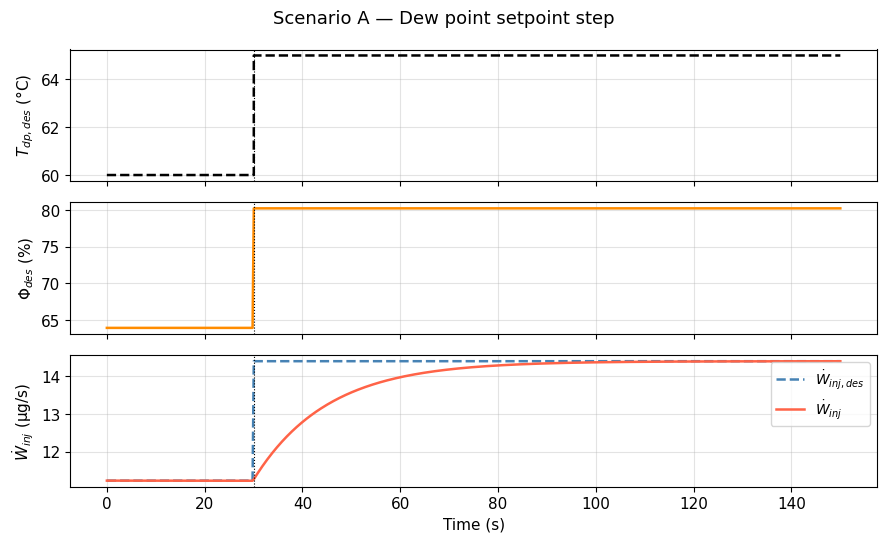

In [7]:
# =========================================================================
# Scenario A — Dew point setpoint step
# =========================================================================
T_dp_A0  = Tfc_nom - 10.0   # K  60 °C initial dew point
T_dp_A1  = Tfc_nom - 5.0    # K  65 °C new dew point
t_step_A = 30.0              # s
T_sim_A  = 150.0             # s

def T_dp_A(t):
    return T_dp_A0 if t < t_step_A else T_dp_A1

hum_A = Humidifier('cathode', T_dp_A0)

def ode_A(t, y):
    hum_A.T_dp_des = T_dp_A(t)
    W_des = hum_A.Winj_setpoint(Pcsm_nom, Wcp_nom, M_air_dry, W_v_amb)
    return [hum_A.dWinj_dt(y[0], W_des)]

W0_A  = Humidifier('cathode', T_dp_A0).Winj_setpoint(Pcsm_nom, Wcp_nom, M_air_dry, W_v_amb)
sol_A = solve_ivp(ode_A, [0, T_sim_A], [W0_A], max_step=0.5, dense_output=True)

t_A    = np.linspace(0, T_sim_A, 600)
Wi_A   = sol_A.sol(t_A)[0]
Tdp_A  = np.array([T_dp_A(t) - 273.15 for t in t_A])
Phi_A  = np.array([Phi_des_from_dp(Tfc_nom, T_dp_A(t)) for t in t_A])
Wdes_A = np.array(
    [Humidifier('cathode', T_dp_A(t)).Winj_setpoint(Pcsm_nom, Wcp_nom, M_air_dry, W_v_amb)
     for t in t_A])

fig, axes = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True)
fig.suptitle('Scenario A — Dew point setpoint step', fontsize=13)

axes[0].step(t_A, Tdp_A, where='post', color='k', linestyle='--')
axes[0].set_ylabel(r'$T_{dp,des}$ (°C)')

axes[1].plot(t_A, Phi_A * 100, color='darkorange')
axes[1].set_ylabel(r'$\Phi_{des}$ (%)')

axes[2].plot(t_A, Wdes_A * 1e6, linestyle='--', color='steelblue',
             label=r'$\dot{W}_{inj,des}$')
axes[2].plot(t_A, Wi_A   * 1e6, color='tomato',
             label=r'$\dot{W}_{inj}$')
axes[2].set_ylabel(r'$\dot{W}_{inj}$ (μg/s)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(fontsize=10)

for ax in axes:
    ax.axvline(t_step_A, color='k', linewidth=0.8, linestyle=':')

fig.tight_layout()
plt.show()

Dew point setpoint : 58.6 °C  (= 60% RH at 70°C)


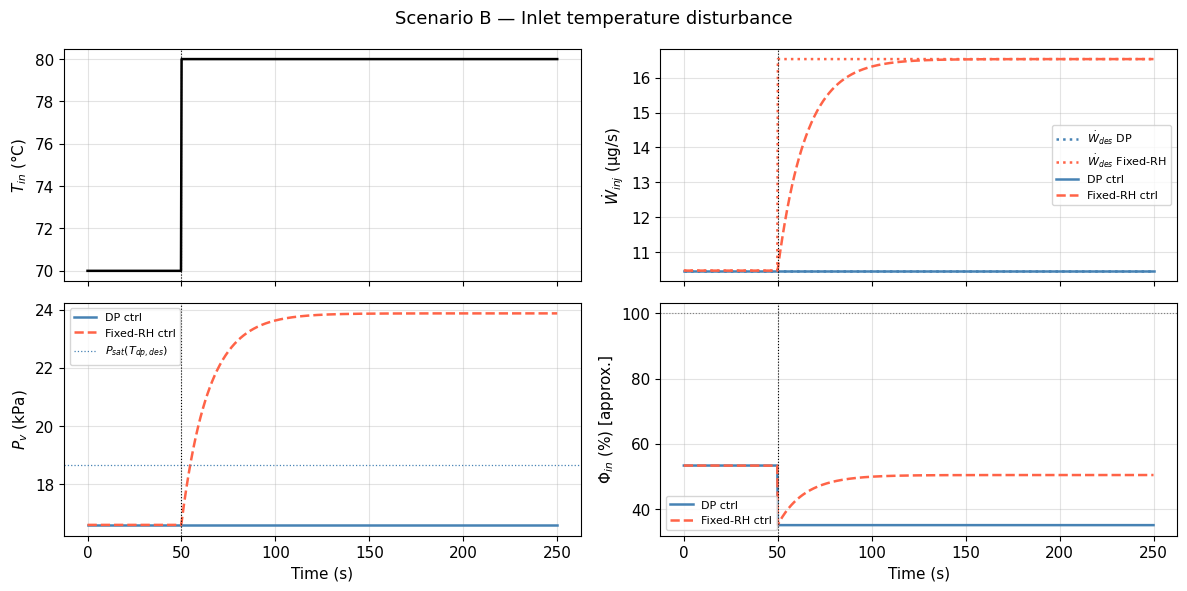


--- Steady-state comparison (after temperature step) ---
Dew point ctrl : W_inj = 10.47 μg/s,  P_v = 16.60 kPa,  Phi_in = 35.1%
Fixed-RH ctrl  : W_inj = 16.53 μg/s,  P_v = 23.87 kPa,  Phi_in = 50.5%
Target dew point partial pressure: 18.67 kPa


In [8]:
# =========================================================================
# Scenario B — Inlet temperature disturbance
#              Dew point control  vs  fixed-RH control
# =========================================================================
T_in_0   = 343.15    # K  70 °C nominal
T_in_1   = 353.15    # K  80 °C after step
t_step_B = 50.0      # s
T_sim_B  = 250.0     # s
Phi_nom  = 0.60      # nominal RH used to initialise both controllers

# Dew point setpoint matched to Phi_nom at the nominal inlet temperature
T_dp_B = Tdp(T_in_0, Phi_nom)
print(f'Dew point setpoint : {T_dp_B - 273.15:.1f} °C'
      f'  (= {Phi_nom*100:.0f}% RH at {T_in_0-273.15:.0f}°C)')

def T_in_B(t):
    return T_in_0 if t < t_step_B else T_in_1

# --- Dew point controller ---
hum_dp = Humidifier('cathode', T_dp_B)

def ode_dp(t, y):
    # Winj_setpoint does NOT depend on T_in (P_sat(T_in) cancels)
    W_des = hum_dp.Winj_setpoint(Pcsm_nom, Wcp_nom, M_air_dry, W_v_amb)
    return [hum_dp.dWinj_dt(y[0], W_des)]

# --- Fixed-RH controller  (Phi_des = Phi_nom = constant) ---
def Winj_fixedPhi(T_in, Phi_fixed=Phi_nom):
    W_v_des = M_H2O * Phi_fixed * Psat(T_in) / Pcsm_nom * (Wcp_nom / M_air_dry)
    return max(0.0, W_v_des - W_v_amb)

def ode_fx(t, y):
    W_des = Winj_fixedPhi(T_in_B(t))
    return [(W_des - y[0]) / tau_hum]

W0_dp  = hum_dp.Winj_setpoint(Pcsm_nom, Wcp_nom, M_air_dry, W_v_amb)
W0_fx  = Winj_fixedPhi(T_in_0)
sol_dp = solve_ivp(ode_dp, [0, T_sim_B], [W0_dp], max_step=0.5, dense_output=True)
sol_fx = solve_ivp(ode_fx, [0, T_sim_B], [W0_fx], max_step=0.5, dense_output=True)

t_B   = np.linspace(0, T_sim_B, 800)
Wi_dp = sol_dp.sol(t_B)[0]
Wi_fx = sol_fx.sol(t_B)[0]
T_B   = np.array([T_in_B(t) for t in t_B])

# Reference (setpoint) signals for the actuator
# DP control: setpoint is constant (P_sat(T_in) cancels, only T_dp_des matters)
Wdes_dp_B = np.full_like(t_B, hum_dp.Winj_setpoint(Pcsm_nom, Wcp_nom, M_air_dry, W_v_amb))
# Fixed-RH control: setpoint tracks T_in step
Wdes_fx_B = np.array([Winj_fixedPhi(T_in_B(t)) for t in t_B])

# Approximate vapour partial pressure at supply manifold inlet
def Pv_approx(W_inj):
    n_v   = (W_inj + W_v_amb) / M_H2O
    n_dry = Wcp_nom / M_air_dry
    return n_v / (n_v + n_dry) * Pcsm_nom

Pv_dp = np.array([Pv_approx(w) for w in Wi_dp])
Pv_fx = np.array([Pv_approx(w) for w in Wi_fx])
Phi_dp_approx = Pv_dp / Psat(T_B)
Phi_fx_approx = Pv_fx / Psat(T_B)

# ---- Plot (2×2) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
fig.suptitle('Scenario B — Inlet temperature disturbance', fontsize=13)

ax_T   = axes[0, 0]
ax_W   = axes[0, 1]
ax_Pv  = axes[1, 0]
ax_Phi = axes[1, 1]

# Top-left: inlet temperature
ax_T.plot(t_B, T_B - 273.15, color='k')
ax_T.set_ylabel('$T_{in}$ (°C)')

# Top-right: water injection + setpoints
ax_W.plot(t_B, Wdes_dp_B * 1e6, linestyle=':', color='steelblue',
          label=r'$\dot{W}_{des}$ DP')
ax_W.plot(t_B, Wdes_fx_B * 1e6, linestyle=':', color='tomato',
          label=r'$\dot{W}_{des}$ Fixed-RH')
ax_W.plot(t_B, Wi_dp * 1e6, color='steelblue',
          label='DP ctrl')
ax_W.plot(t_B, Wi_fx * 1e6, color='tomato', linestyle='--',
          label='Fixed-RH ctrl')
ax_W.set_ylabel(r'$\dot{W}_{inj}$ (μg/s)')
ax_W.legend(fontsize=8)

# Bottom-left: vapour partial pressure
ax_Pv.plot(t_B, Pv_dp / 1e3, color='steelblue', label='DP ctrl')
ax_Pv.plot(t_B, Pv_fx / 1e3, color='tomato', linestyle='--', label='Fixed-RH ctrl')
ax_Pv.axhline(Psat(T_dp_B) / 1e3, color='steelblue', linewidth=0.9,
              linestyle=':', label=r'$P_{sat}(T_{dp,des})$')
ax_Pv.set_ylabel(r'$P_v$ (kPa)')
ax_Pv.set_xlabel('Time (s)')
ax_Pv.legend(fontsize=8)

# Bottom-right: inlet RH
ax_Phi.plot(t_B, Phi_dp_approx * 100, color='steelblue', label='DP ctrl')
ax_Phi.plot(t_B, Phi_fx_approx * 100, color='tomato', linestyle='--', label='Fixed-RH ctrl')
ax_Phi.axhline(100, color='gray', linewidth=0.8, linestyle=':')
ax_Phi.set_ylabel(r'$\Phi_{in}$ (%) [approx.]')
ax_Phi.set_xlabel('Time (s)')
ax_Phi.legend(fontsize=8)

for ax in axes.flat:
    ax.axvline(t_step_B, color='k', linewidth=0.8, linestyle=':')

fig.tight_layout()
plt.show()

print()
print('--- Steady-state comparison (after temperature step) ---')
ss = -1   # last point
print(f'Dew point ctrl : W_inj = {Wi_dp[ss]*1e6:.2f} μg/s,  '
      f'P_v = {Pv_dp[ss]/1e3:.2f} kPa,  Phi_in = {Phi_dp_approx[ss]*100:.1f}%')
print(f'Fixed-RH ctrl  : W_inj = {Wi_fx[ss]*1e6:.2f} μg/s,  '
      f'P_v = {Pv_fx[ss]/1e3:.2f} kPa,  Phi_in = {Phi_fx_approx[ss]*100:.1f}%')
print(f'Target dew point partial pressure: {Psat(T_dp_B)/1e3:.2f} kPa')

## 6   Startup Simulation

### Boiler + Dew Point Control vs. Current Model

**Scenario:** cold start at ambient temperature $T_{in}(0) = 25\,^\circ\mathrm{C}$.
The boiler warms up to $T_{des} = 70\,^\circ\mathrm{C}$ with $\tau_{boil} = 60\,\mathrm{s}$
and dew point depression $\Delta T = 10\,\mathrm{K}$.

| | $T_{in}$ | $\Phi_{des}$ | $\dot{W}_{inj,des}$ |
|---|---|---|---|
| **Current model** | constant $T_{fc}$ | constant $\Phi_{nom}$ | constant |
| **Boiler + DP ctrl** | first-order warmup | adaptive via $\Delta T$ | scales with $T_{in}$ |

The current model applies the **full steady-state injection rate immediately**,
assuming the gas is already at $T_{fc}$.
In a real cold start the gas is still cold, so $P_{sat}(T_{in})$ is much lower
and the same injection causes $\Phi_{in} \gg 100\%$ — a **condensation risk**.

The boiler-aware controller scales injection with the measured $T_{in}(t)$,
keeping $\Phi_{in}$ below saturation throughout the warmup.

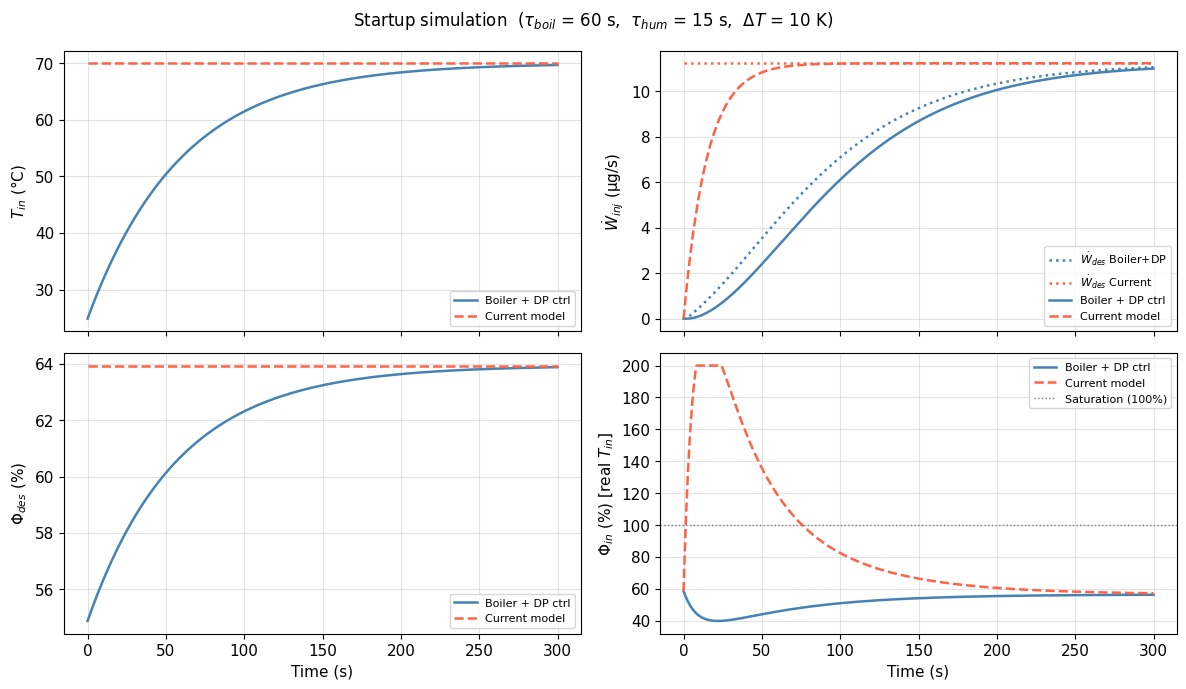

Steady-state target : Phi_des = 63.9%  (T_dp_des = 60.0°C)
Peak Phi_in  Boiler + DP ctrl : 58%
Peak Phi_in  Current model    : 217%  <-- condensation risk if > 100%


In [9]:
# =========================================================================
# Startup simulation  —  Boiler + DP control  vs  current model
# =========================================================================
Delta_T_dp = 10.0      # K   dew point depression
tau_boil   = 60.0      # s   boiler thermal time constant
T_boil_des = Tfc_nom   # K   boiler setpoint = fuel cell temperature
T_sim_st   = 300.0     # s   simulation duration

boiler    = Boiler(T_des=T_boil_des, tau=tau_boil)
hum_start = Humidifier('cathode', T_dp_des=T_boil_des - Delta_T_dp)

# ── New model: boiler + depression-based dew point control ───────────────────
def ode_boiler_dp(t, y):
    T_in, W_inj = y
    dT_in = boiler.dT_dt(T_in)
    # Dew point setpoint tracks the measured inlet temperature
    hum_start.T_dp_des = T_in - Delta_T_dp
    W_des  = hum_start.Winj_setpoint(Pcsm_nom, Wcp_nom, M_air_dry, W_v_amb)
    dW_inj = hum_start.dWinj_dt(W_inj, W_des)
    return [dT_in, dW_inj]

# ── Current model: T_in = Tfc_nom = const, fixed Phi_des ─────────────────────
Phi_des_ss    = Psat(T_boil_des - Delta_T_dp) / Psat(T_boil_des)   # steady-state RH
W_inj_des_cur = max(0.0, M_H2O * Phi_des_ss * Psat(Tfc_nom) / Pcsm_nom
                    * (Wcp_nom / M_air_dry) - W_v_amb)

def ode_current_startup(t, y):
    return [(W_inj_des_cur - y[0]) / tau_hum]

# Cold-start initial conditions: T_in = ambient, W_inj = 0
sol_boiler  = solve_ivp(ode_boiler_dp,       [0, T_sim_st], [Text, 0.0],
                        max_step=0.5, dense_output=True)
sol_current = solve_ivp(ode_current_startup, [0, T_sim_st], [0.0],
                        max_step=0.5, dense_output=True)

# ── Post-process ─────────────────────────────────────────────────────
t_st = np.linspace(0, T_sim_st, 1000)

res_boiler = sol_boiler.sol(t_st)
T_in_new   = res_boiler[0]                        # boiler outlet temperature
Wi_new     = res_boiler[1]                        # injection (boiler + DP ctrl)
Wi_cur     = sol_current.sol(t_st)[0]             # injection (current model)
T_in_cur   = np.full_like(t_st, Tfc_nom)          # current model assumes const T_in

# RH setpoints
Phi_des_new = Psat(T_in_new - Delta_T_dp) / Psat(T_in_new)   # adaptive
Phi_des_cur = np.full_like(t_st, Phi_des_ss)                  # constant

# Reference (setpoint) signals for the actuator
# New model: setpoint evolves as boiler warms up (Psat(T_in) no longer cancels)
Wdes_new = np.array([
    max(0.0, M_H2O * Psat(T_in_new[i] - Delta_T_dp) / Pcsm_nom
             * (Wcp_nom / M_air_dry) - W_v_amb)
    for i in range(len(t_st))
])
# Current model: constant setpoint from the start
Wdes_cur = np.full_like(t_st, W_inj_des_cur)

# Approximate inlet Phi using REAL T_in (boiler profile) for both models
Pv_new = np.array([Pv_approx(w) for w in Wi_new])
Pv_cur = np.array([Pv_approx(w) for w in Wi_cur])
Phi_in_new = Pv_new / Psat(T_in_new)
Phi_in_cur = Pv_cur / Psat(T_in_new)     # real T_in applied to current model too

# ── Plot (2×2) ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
fig.suptitle(
    fr'Startup simulation  ($\tau_{{boil}}$ = {tau_boil:.0f} s,  '
    fr'$\tau_{{hum}}$ = {tau_hum:.0f} s,  $\Delta T$ = {Delta_T_dp:.0f} K)',
    fontsize=12)

ax_T   = axes[0, 0]
ax_W   = axes[0, 1]
ax_Phi_des = axes[1, 0]
ax_Phi_in  = axes[1, 1]

kw_new = dict(color='steelblue', label='Boiler + DP ctrl')
kw_cur = dict(color='tomato', linestyle='--', label='Current model')

# Top-left: inlet temperature
ax_T.plot(t_st, T_in_new - 273.15, **kw_new)
ax_T.plot(t_st, T_in_cur - 273.15, **kw_cur)
ax_T.set_ylabel('$T_{in}$ (°C)')
ax_T.legend(fontsize=8)

# Top-right: water injection + setpoints
ax_W.plot(t_st, Wdes_new * 1e6, linestyle=':', color='steelblue',
          label=r'$\dot{W}_{des}$ Boiler+DP')
ax_W.plot(t_st, Wdes_cur * 1e6, linestyle=':', color='tomato',
          label=r'$\dot{W}_{des}$ Current')
ax_W.plot(t_st, Wi_new * 1e6, **kw_new)
ax_W.plot(t_st, Wi_cur * 1e6, **kw_cur)
ax_W.set_ylabel(r'$\dot{W}_{inj}$ (μg/s)')
ax_W.legend(fontsize=8)

# Bottom-left: RH setpoint
ax_Phi_des.plot(t_st, Phi_des_new * 100, **kw_new)
ax_Phi_des.plot(t_st, Phi_des_cur * 100, **kw_cur)
ax_Phi_des.set_ylabel(r'$\Phi_{des}$ (%)')
ax_Phi_des.set_xlabel('Time (s)')
ax_Phi_des.legend(fontsize=8)

# Bottom-right: actual inlet RH
ax_Phi_in.plot(t_st, np.clip(Phi_in_new * 100, 0, 200), **kw_new)
ax_Phi_in.plot(t_st, np.clip(Phi_in_cur * 100, 0, 200), **kw_cur)
ax_Phi_in.axhline(100, color='gray', linewidth=1.0, linestyle=':',
                  label='Saturation (100%)')
ax_Phi_in.set_ylabel(r'$\Phi_{in}$ (%) [real $T_{in}$]')
ax_Phi_in.set_xlabel('Time (s)')
ax_Phi_in.legend(fontsize=8)

fig.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────
print(f'Steady-state target : Phi_des = {Phi_des_ss*100:.1f}%  '
      f'(T_dp_des = {T_boil_des - Delta_T_dp - 273.15:.1f}°C)')
print(f'Peak Phi_in  Boiler + DP ctrl : {Phi_in_new.max()*100:.0f}%')
print(f'Peak Phi_in  Current model    : {Phi_in_cur.max()*100:.0f}%  '
      f'<-- condensation risk if > 100%')